# Step 1 — Structure setup & Interface detection (5 Å)

This notebook recreates the Step 1 pipeline:

- Clean `6m0j.cif` using the available `basic_setup.py` and biobb tools
- Produce `6m0j_fixed.pdb` and `6m0j_fixed.pdbqt`
- Detect interface residues between **chain A** (ACE2) and **chain E** (RBD) using a **5 Å** cutoff
- Export `interface_residues.csv`
- Produce a PyMOL session file highlighting the interface (`interface_residues.pse`).

## Notes before running

1. This notebook assumes you have a conda environment with the required packages installed:

```bash
conda create -n energy_project python=3.10 -y
conda activate energy_project
conda install -c bioconda biobb_structure_checking biopython -y
conda install -c conda-forge pymol-open-source -y
pip install numpy pandas
```

2. The notebook expects your project folder to contain the files you listed (e.g. `6m0j.cif`, `basic_setup.py`, `forcefield.py`, NACCESS folder, etc.) and will always re-run the cleaning step (as requested).

3. If PyMOL or biobb are not installed, run the installation step above before executing the cells.

Run the cells in order.

In [1]:
import os
from pathlib import Path
import subprocess
import sys
import numpy as np
import pandas as pd
from Bio.PDB import PDBParser, NeighborSearch, Selection

# Set project and output paths
PROJECT_DIR = Path.cwd()  # adjust if running from a different dir
STEP1_DIR = PROJECT_DIR / 'Step1_Interface'
STEP1_DIR.mkdir(exist_ok=True)

# Input files (assumed to be in the project root)
CIF_FILE = PROJECT_DIR / 'Structure_checking' / '6m0j.cif'
RAW_PDB = PROJECT_DIR / 'Structure_checking' / '6m0j.cif'
CLEANED_PDB = PROJECT_DIR / 'Structure_checking' / '6m0j_fixed.pdb'
CLEANED_PDBQT = PROJECT_DIR / 'Structure_checking' / '6m0j_fixed.pdbqt'

INTERFACE_CSV = STEP1_DIR / 'interface_residues.csv'
PYMOL_SESSION = STEP1_DIR / 'interface_residues.pse'

print('Project dir:', PROJECT_DIR)
print('Step1 output dir:', STEP1_DIR)


Project dir: /home/oriol/Desktop/a/BioPhysics-master/BioPhysics-master/Energy_analysis_project
Step1 output dir: /home/oriol/Desktop/a/BioPhysics-master/BioPhysics-master/Energy_analysis_project/Step1_Interface


## 2) Load cleaned structure and inspect chains

If the cleaning step above produced `6m0j_fixed.pdbqt` or `6m0j_fixed.pdb` in this directory, the notebook
will use them. Otherwise, it will look for files in the project root. We earlier confirmed the chains are **A** and **E**.

In [2]:
pdb_to_load = None
if CLEANED_PDB.exists():
    pdb_to_load = str(CLEANED_PDB)
elif (PROJECT_DIR / '6m0j_fixed.pdb').exists():
    pdb_to_load = str(PROJECT_DIR / '6m0j_fixed.pdb')
    
elif (PROJECT_DIR / '6m0j_fixed.pdbqt').exists():
    # If only pdbqt exists, try replacing extension
    pdb_to_load = str(PROJECT_DIR / '6m0j_fixed.pdbqt')

elif (PROJECT_DIR / '6m0j.pdb').exists():
    pdb_to_load = str(PROJECT_DIR / '6m0j.pdb')

else:
    raise FileNotFoundError('No cleaned PDB found. Please run the cleaning step or place 6m0j_fixed.pdb in the project root.')

print('Using PDB file:', pdb_to_load)

parser = PDBParser(QUIET=True)
structure = parser.get_structure('6M0J', pdb_to_load)
models = list(structure.get_models())
print('Number of models:', len(models))

# List chains and basic stats
chains = [(chain.id, len(list(chain.get_residues()))) for chain in structure.get_chains()]
print('Chains and residue counts:')
for c in chains:
    print(c)


Using PDB file: /home/oriol/Desktop/a/BioPhysics-master/BioPhysics-master/Energy_analysis_project/Structure_checking/6m0j_fixed.pdb
Number of models: 1
Chains and residue counts:
('A', 597)
('E', 194)


## 3) Interface detection (5 Å) between chain A (ACE2) and chain E (RBD)

This cell computes atom-atom distances and finds residues with any atom within 5.0 Å.


In [3]:
from Bio.PDB import NeighborSearch

CUTOFF = 5.0
chain_A = None
chain_E = None
for model in structure:
    for chain in model:
        if chain.id == 'A':
            chain_A = chain
        elif chain.id == 'E':
            chain_E = chain

if chain_A is None or chain_E is None:
    raise ValueError('Could not find chain A and/or chain E in structure. Found chains: {}'
                     .format([c.id for c in structure.get_chains()]))

# Build atom lists
atoms_A = list(chain_A.get_atoms())
atoms_E = list(chain_E.get_atoms())

ns = NeighborSearch(atoms_A + atoms_E)

contacts = []
    
for atom_a in atoms_A:
    close = ns.search(atom_a.coord, CUTOFF)
    for atom in close:
        # only consider atoms from chain E
        if atom.get_parent().get_parent().id == 'E':
            dist = np.linalg.norm(atom.coord - atom_a.coord)
            if dist <= CUTOFF:
                res_a = atom_a.get_parent()
                res_e = atom.get_parent()
                contacts.append((res_a.get_id()[1], res_a.get_resname(), 'A', res_e.get_id()[1], res_e.get_resname(), 'E', float(dist)))

contacts_df = pd.DataFrame(contacts, columns=['resA_idx','resA_name','chainA','resE_idx','resE_name','chainE','distance'])
contacts_df = contacts_df.sort_values('distance')
    
print('Total contacts found (atom pairs):', len(contacts_df))
display(contacts_df.head(20))

# Create per-residue summarized list (min distance per residue pair)
grouped = contacts_df.groupby(['resA_idx','resA_name','chainA','resE_idx','resE_name','chainE']).distance.min().reset_index()
grouped = grouped.sort_values('distance')
    
display(grouped.head(40))

# Save CSV of unique interface residues (both sides)
resA_unique = grouped[['resA_idx','resA_name','chainA','distance']].rename(columns={'resA_idx':'res_idx','resA_name':'res_name','chainA':'chain'})
resE_unique = grouped[['resE_idx','resE_name','chainE','distance']].rename(columns={'resE_idx':'res_idx','resE_name':'res_name','chainE':'chain'})
res_all = pd.concat([resA_unique, resE_unique], ignore_index=True).drop_duplicates(['res_idx','chain'])
res_all = res_all.sort_values(['chain','res_idx'])
res_all.to_csv(INTERFACE_CSV, index=False)
print('Wrote interface residues CSV to', INTERFACE_CSV)


Total contacts found (atom pairs): 2040


,resA_idx,resA_name,chainA,resE_idx,resE_name,chainE,distance
1576,353,LYS,A,502,GLY,E,1.728296
944,38,ASP,A,449,TYR,E,1.844388
58,24,GLN,A,487,ASN,E,1.847695
452,30,ASP,A,456,PHE,E,1.919340
428,30,ASP,A,417,LYS,E,1.977995
346,28,PHE,A,489,TYR,E,2.030994
1312,82,MET,A,486,PHE,E,2.053859
2006,357,ARG,A,500,THR,E,2.137240
838,34,HIE,A,453,TYR,E,2.203000
1156,42,GLN,A,449,TYR,E,2.217373


,resA_idx,resA_name,chainA,resE_idx,resE_name,chainE,distance
70,353,LYS,A,502,GLY,E,1.728296
32,38,ASP,A,449,TYR,E,1.844388
7,24,GLN,A,487,ASN,E,1.847695
17,30,ASP,A,456,PHE,E,1.919340
15,30,ASP,A,417,LYS,E,1.977995
14,28,PHE,A,489,TYR,E,2.030994
49,82,MET,A,486,PHE,E,2.053859
80,357,ARG,A,500,THR,E,2.137240
26,34,HIE,A,453,TYR,E,2.203000
41,42,GLN,A,449,TYR,E,2.217373


Wrote interface residues CSV to /home/oriol/Desktop/a/BioPhysics-master/BioPhysics-master/Energy_analysis_project/Step1_Interface/interface_residues.csv


## 4) Generate PyMOL session to visualize interface

This cell writes a short PyMOL script that loads the cleaned PDB, colors chains, highlights interface residues,
and saves a `.pse` session. Run the generated commands inside PyMOL if the API is not available.


In [4]:
pymol_script = STEP1_DIR / 'make_interface_pse.pml'
with open(pymol_script, 'w') as fh:
    fh.write(f"load {pdb_to_load}\n")
    fh.write('hide everything\n')
    # fh.write('show cartoon\n')
    fh.write('color gray, all\n')
    fh.write('color cyan, chain A\n')
    fh.write('color orange, chain E\n')

    # Read interface CSV and build selections
    df = pd.read_csv(INTERFACE_CSV)
    selA = df[df.chain=='A']
    selE = df[df.chain=='E']
    if not selA.empty:
        selA_list = '+'.join([f"resi {int(x)} and chain A" for x in selA.res_idx])
        fh.write(f'select interface_A, {selA_list}\n')
        fh.write('show sticks, interface_A\n')
        fh.write('label interface_A and name CA, resi+" "+resn\n')
    if not selE.empty:
        selE_list = '+'.join([f"resi {int(x)} and chain E" for x in selE.res_idx])
        fh.write(f'select interface_E, {selE_list}\n')
        fh.write('show sticks, interface_E\n')
        fh.write('label interface_E and name CA, resi+" "+resn\n')

    fh.write(f'save {PYMOL_SESSION}\n')

print('Wrote PyMOL script to', pymol_script)

print('\nTo generate the .pse, open PyMOL and run:\n')
print(f'    @{pymol_script}')


Wrote PyMOL script to /home/oriol/Desktop/a/BioPhysics-master/BioPhysics-master/Energy_analysis_project/Step1_Interface/make_interface_pse.pml

To generate the .pse, open PyMOL and run:

    @/home/oriol/Desktop/a/BioPhysics-master/BioPhysics-master/Energy_analysis_project/Step1_Interface/make_interface_pse.pml


## Done — Next steps

- Run the cells in order. If `basic_setup.py` does not provide a CLI as assumed, edit the cell that runs it or run the tutorial `6m0j_check_tutorial.ipynb` manually.

- After generating `interface_residues.csv` and the PyMOL script, open PyMOL and run the script to save the session (`.pse`).

- Once you have the CSV and session, we can proceed to Step 2 (energy calculations). I will prepare a template energy script that uses the cleaned PDB/PDBQT and the residue list.


In [5]:
# Cell 1: imports, paths and configuration
import os, sys, subprocess
from pathlib import Path
import numpy as np
import pandas as pd
from math import sqrt, exp
from Bio.PDB import PDBParser, PDBIO, Select
from Bio.PDB.NACCESS import NACCESS_atomic

# Adjust this if you run notebook from another folder
PROJECT_DIR = Path.cwd()
STEP1_DIR = PROJECT_DIR / "Step1_Interface"
STRUCT_DIR = PROJECT_DIR / "Structure_checking"

PDB_FILE = STRUCT_DIR / "6m0j_fixed.pdb"
PDBQT_FILE = STRUCT_DIR / "6m0j_fixed.pdbqt"
INTERFACE_CSV = STEP1_DIR / "interface_residues.csv"

# forcefield file / module
FORCEFIELD_PY = PROJECT_DIR / "forcefield.py"  # your forcefield module
VDWPRM = PROJECT_DIR / "data" / "vdwprm"       # path used by your project; update if different

NACCESS_BIN = PROJECT_DIR / "NACCESS" / "NACCESS" / "naccess"
    
print("Using PDB:", PDB_FILE)
print("Using PDBQT:", PDBQT_FILE)
print("Using interface CSV:", INTERFACE_CSV)
print("NACCESS binary:", NACCESS_BIN)

# Basic safety checks
if not PDB_FILE.exists():
    raise FileNotFoundError(f"PDB file not found: {PDB_FILE}")
if not PDBQT_FILE.exists():
    raise FileNotFoundError(f"PDBQT file not found: {PDBQT_FILE}")
if not INTERFACE_CSV.exists():
    raise FileNotFoundError(f"interface_residues.csv not found: {INTERFACE_CSV}")
if not FORCEFIELD_PY.exists():
    raise FileNotFoundError(f"forcefield.py not found: {FORCEFIELD_PY}")
if not NACCESS_BIN.exists():
    raise FileNotFoundError(f"NACCESS binary not found at {NACCESS_BIN}; edit NACCESS_BIN variable to correct path.")


Using PDB: /home/oriol/Desktop/a/BioPhysics-master/BioPhysics-master/Energy_analysis_project/Structure_checking/6m0j_fixed.pdb
Using PDBQT: /home/oriol/Desktop/a/BioPhysics-master/BioPhysics-master/Energy_analysis_project/Structure_checking/6m0j_fixed.pdbqt
Using interface CSV: /home/oriol/Desktop/a/BioPhysics-master/BioPhysics-master/Energy_analysis_project/Step1_Interface/interface_residues.csv
NACCESS binary: /home/oriol/Desktop/a/BioPhysics-master/BioPhysics-master/Energy_analysis_project/NACCESS/NACCESS/naccess


In [6]:
# Cell 2: load forcefield and helper functions
import importlib.util
spec = importlib.util.spec_from_file_location("forcefield", str(FORCEFIELD_PY))
ff_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ff_mod)

# load VdwParamset (class name depending on your file; example uses VdwParamset)
VdwParamset = getattr(ff_mod, "VdwParamset")
vdw_params = VdwParamset(str(VDWPRM))

# Mehler-Solmajer dielectric function (from your doc)
def mehler_solmajer_eps(r):
    # r in Å
    # ε_r = 86.9525 / (1 - 7.7839 * exp(-0.3153 * r) - 8.5525)
    # Note: the formula is taken verbatim from the assignment sheet.
    denom = (1.0 - 7.7839 * np.exp(-0.3153 * r) - 8.5525)
    # avoid division by zero / negative denom numerical issues
    if denom == 0:
        return 80.0
    return 86.9525 / denom

# Lorentz-Berthelot combination rules
def combine_eps(eps1, eps2):
    return sqrt(eps1 * eps2)

def combine_sigma(sig1, sig2):
    return 0.5 * (sig1 + sig2)

# LJ potential: 4*eps*((sigma/r)**12 - (sigma/r)**6)
def lj_energy(eps_ij, sigma_ij, r):
    if r == 0:
        return 0.0
    sr6 = (sigma_ij / r) ** 6
    return 4.0 * eps_ij * (sr6 * sr6 - sr6)

# electrostatic energy with 332.16 conversion factor
def electrostatic(qi, qj, r):
    if r == 0:
        return 0.0
    eps_r = mehler_solmajer_eps(r)
    return 332.16 * (qi * qj) / (eps_r * r)

# Safe float parse
def safe_float(x, default=0.0):
    try:
        return float(x)
    except:
        return default


In [7]:
# Cell 3: parse PDB + PDBQT and attach charges/atom types to atoms
from Bio.PDB import PDBParser

parser = PDBParser(QUIET=True)
structure = parser.get_structure("STRUCT", str(PDB_FILE))
model = next(structure.get_models())

# Read PDBQT lines and try to auto-detect last token = atom type and last numeric = charge
pdbqt_lines = [ln.rstrip("\n") for ln in open(PDBQT_FILE, "r", encoding="utf-8", errors="ignore")]

# Build list of params indexed by atom serial order (1-based)
params = [None]  # index 0 unused to allow direct indexing by serial_number
for ln in pdbqt_lines:
    if ln.startswith("TER") or ln.strip() == "":
        continue
    parts = ln.split()
    # attempt to find a numeric token (charge) and the last token as atom type
    charge = None
    atom_type = None
    # find last numeric-like token scanning from the end
    for tok in reversed(parts):
        try:
            c = float(tok)
            charge = c
            break
        except:
            continue
    # atom type assumed to be last token if not numeric
    if len(parts) > 0:
        last = parts[-1]
        try:
            float(last)
            # last is numeric -> atom type likely before it
            atom_type = parts[-2] if len(parts) >= 2 else last
        except:
            atom_type = last
    if charge is None:
        # fallback: 0.0
        charge = 0.0
    params.append({'charge': charge, 'type': atom_type})

# Ensure atom.serial_number are 1..N
i = 1
for at in structure.get_atoms():
    # Some PDBs may not have serial_number attribute; assign sequentially
    try:
        at.serial_number = at.serial_number if hasattr(at, "serial_number") else i
    except:
        at.serial_number = i
    i += 1

# Attach params to atoms (safe mapping: if index out of range, use defaults)
total_charge = 0.0
for at in structure.get_atoms():
    idx = at.serial_number
    if idx < len(params) and params[idx] is not None:
        at.xtra['charge'] = safe_float(params[idx]['charge'], 0.0)
        at.xtra['atom_type'] = params[idx].get('type', 'X')
    else:
        at.xtra['charge'] = 0.0
        at.xtra['atom_type'] = 'X'
    # attach vdw param object if available (may raise if type missing)
    try:
        at.xtra['vdw'] = vdw_params.at_types[at.xtra['atom_type']]
    except Exception as e:
        # fallback: create a minimal object-like dict if missing
        at.xtra['vdw'] = type("AT", (), {"eps":0.0, "sig":0.0, "fsrf":0.0, "rvdw":0.0})
    total_charge += at.xtra['charge']

print("Total assigned charge (sum over atoms):", total_charge)


Total assigned charge (sum over atoms): -26.11100000000012


In [8]:
# Cell 4: compute ASA using Biopython NACCESS_atomic

# NOTE: Ensure these imports are available in your notebook or environment
from Bio.PDB import Select, PDBIO, PDBParser
from Bio.PDB.NACCESS import NACCESS_atomic # Assuming this was imported earlier

# helper class to write only one chain
class ChainSelect(Select):
    def __init__(self, chain_id):
        self.chain_id = chain_id
    def accept_chain(self, chain):
        return (chain.id == self.chain_id)

# Run NACCESS on complex (structure model)
print("Computing ASA for complex (all chains)...")
srf_complex = NACCESS_atomic(model, naccess_binary=str(NACCESS_BIN))
# NACCESS_atomic populates .xtra['EXP_NACCESS'] for atoms (Biopython specific behaviour)

# Save chain A and chain E PDB files for isolated ASA calculation
chainA_pdb = STEP1_DIR / "chainA_isolated.pdb"
chainE_pdb = STEP1_DIR / "chainE_isolated.pdb"
io = PDBIO()
io.set_structure(structure)

# CORRECTED LINES: Use str() around chainA_pdb and chainE_pdb
# write chain A
io.save(str(chainA_pdb), ChainSelect("A"))
# write chain E
io.save(str(chainE_pdb), ChainSelect("E"))

# load them and compute ASA per chain
parser = PDBParser(QUIET=True)
struct_A = parser.get_structure("A", str(chainA_pdb))
struct_E = parser.get_structure("E", str(chainE_pdb))

print("Computing ASA for isolated chain A...")
srf_A = NACCESS_atomic(struct_A[0], naccess_binary=str(NACCESS_BIN))
print("Computing ASA for isolated chain E...")
srf_E = NACCESS_atomic(struct_E[0], naccess_binary=str(NACCESS_BIN))

# After these calls, each atom in model should have .xtra['EXP_NACCESS'] with ASA value
# We'll extract ASA per-atom into dictionaries keyed by (chain, resid, atom_name)
def atom_key(atom):
    res = atom.get_parent()
    chain = res.get_parent()
    return (chain.id, res.get_id()[1], atom.get_name())

asa_complex = {}
for atom in model.get_atoms():
    try:
        asa = atom.xtra.get('EXP_NACCESS', 0.0)
    except:
        asa = 0.0
    asa_complex[atom_key(atom)] = float(asa)

# For isolated chain A
asa_A = {}
for atom in struct_A[0].get_atoms():
    try:
        asa = atom.xtra.get('EXP_NACCESS', 0.0)
    except:
        asa = 0.0
    # Note: Use the chain ID "A" explicitly for the key since struct_A contains only chain A
    k = ("A", atom.get_parent().get_id()[1], atom.get_name())
    asa_A[k] = float(asa)

# For isolated chain E
asa_E = {}
for atom in struct_E[0].get_atoms():
    try:
        asa = atom.xtra.get('EXP_NACCESS', 0.0)
    except:
        asa = 0.0
    # Note: Use the chain ID "E" explicitly for the key since struct_E contains only chain E
    k = ("E", atom.get_parent().get_id()[1], atom.get_name())
    asa_E[k] = float(asa)

print("Collected ASA values for complex and isolated chains.")

Computing ASA for complex (all chains)...
Computing ASA for isolated chain A...
Computing ASA for isolated chain E...
Collected ASA values for complex and isolated chains.


In [9]:
# Cell 5: prepare atom lists for interface residues
iface = pd.read_csv(INTERFACE_CSV)
# we'll take both chains' residues, but restrict calculations to those residues
residues_A = sorted(iface[iface['chain']=='A']['res_idx'].unique().tolist())
residues_E = sorted(iface[iface['chain']=='E']['res_idx'].unique().tolist())

print("Interface residues A:", residues_A[:20], "... total", len(residues_A))
print("Interface residues E:", residues_E[:20], "... total", len(residues_E))

# Build atom lists restricted to interface residues for speed
atoms_A = []
atoms_E = []
for res in model.get_residues():
    cid = res.get_parent().id
    rid = res.get_id()[1]
    if cid == 'A' and rid in residues_A:
        for at in res.get_atoms():
            atoms_A.append(at)
    if cid == 'E' and rid in residues_E:
        for at in res.get_atoms():
            atoms_E.append(at)

print("Atoms selected — A:", len(atoms_A), "E:", len(atoms_E))


Interface residues A: [19, 24, 27, 28, 30, 31, 34, 35, 37, 38, 41, 42, 45, 79, 82, 83, 324, 325, 326, 330] ... total 29
Interface residues E: [403, 417, 445, 446, 447, 449, 453, 455, 456, 473, 475, 476, 477, 484, 486, 487, 489, 490, 493, 495] ... total 30
Atoms selected — A: 458 E: 471


In [10]:
# Cell 6: compute pairwise electrostatic & vdw energies and solvation differences
# We'll compute energies atom-atom when atoms belong to different chains (A vs E).
from collections import defaultdict
per_atom_data = {}  # store attributes per atom key
# Pre-fill per-atom properties: charge, vdw eps/sig, fsrf (solvation param), rvdw(optional)
for at in atoms_A + atoms_E:
    key = atom_key(at)
    charge = at.xtra.get('charge', 0.0)
    vdw_obj = at.xtra.get('vdw', None)
    eps = getattr(vdw_obj, 'eps', 0.0)
    sig = getattr(vdw_obj, 'sig', 0.0)
    fsrf = getattr(vdw_obj, 'fsrf', 0.0)
    rvdw = getattr(vdw_obj, 'rvdw', getattr(vdw_obj, 'rvdw', 0.0))
    asa_c = asa_complex.get(key, 0.0)
    asa_iso = asa_A.get(key, None) if key[0]=='A' else asa_E.get(key, None)
    # If isolated ASA not found, assume 0.0 (shouldn't happen ideally)
    if asa_iso is None:
        asa_iso = 0.0
    per_atom_data[key] = {'atom': at, 'charge': charge, 'eps': eps, 'sig': sig, 'fsrf': fsrf,
                         'asa_complex': asa_c, 'asa_isolated': asa_iso}

# Compute pairwise interactions
pairwise_records = []
# To reduce double counting we will iterate over atoms_A x atoms_E (only cross-chain)
for at_a in atoms_A:
    for at_e in atoms_E:
        r = np.linalg.norm(at_a.coord - at_e.coord)
        if r == 0:
            continue
        key_a = atom_key(at_a)
        key_e = atom_key(at_e)
        # electrostatics
        q_a = per_atom_data[key_a]['charge']
        q_e = per_atom_data[key_e]['charge']
        E_elec = electrostatic(q_a, q_e, r)
        # vdw combine
        eps_ij = combine_eps(per_atom_data[key_a]['eps'], per_atom_data[key_e]['eps'])
        sigma_ij = combine_sigma(per_atom_data[key_a]['sig'], per_atom_data[key_e]['sig'])
        E_vdw = lj_energy(eps_ij, sigma_ij, r)
        pairwise_records.append({'atomA': key_a, 'atomE': key_e, 'r': r, 'E_elec': E_elec, 'E_vdw': E_vdw})

# Convert to DataFrame
pair_df = pd.DataFrame(pairwise_records)
print("Computed pairwise interactions:", len(pair_df))
pair_df.head()


Computed pairwise interactions: 215718


,atomA,atomE,r,E_elec,E_vdw
0,"(A, 19, N)","(E, 403, N)",28.444715,-0.202743,-1.512859e-06
1,"(A, 19, N)","(E, 403, CA)",28.961197,-0.086662,-1.133067e-06
2,"(A, 19, N)","(E, 403, C)",29.679558,0.471225,-9.781606e-07
3,"(A, 19, N)","(E, 403, O)",29.316687,-0.377729,-1.066777e-06
4,"(A, 19, N)","(E, 403, CB)",27.869812,0.025437,-1.426757e-06


In [11]:
# Cell 7: aggregate energies per residue and compute solvation contributions
# initialize residue accumulators
res_energy = defaultdict(lambda: {'E_elec':0.0, 'E_vdw':0.0, 'delta_solv':0.0})

# Sum pairwise contributions into residues (note: pair_df only contains A-E cross interactions)
for _, row in pair_df.iterrows():
    a_key = row['atomA']
    e_key = row['atomE']
    # residue identifiers
    resA = ('A', a_key[1], a_key[2])  # (chain, res_idx, res_name)
    resE = ('E', e_key[1], e_key[2])
    # accumulate half to each residue? No — these interactions contribute to interface energy; we'll record per-res residue contribution
    res_energy[('A', a_key[1])] ['E_elec'] += row['E_elec']
    res_energy[('A', a_key[1])] ['E_vdw'] += row['E_vdw']
    res_energy[('E', e_key[1])] ['E_elec'] += row['E_elec']
    res_energy[('E', e_key[1])] ['E_vdw'] += row['E_vdw']

# Compute solvation delta per atom and sum per residue: sigma_i * (ASA_complex - ASA_isolated)
for key, props in per_atom_data.items():
    chain, resid, atomname = key
    fsrf = props['fsrf']
    dASA = props['asa_complex'] - props['asa_isolated']
    deltaG_atom_solv = fsrf * dASA
    res_energy[(chain, resid)]['delta_solv'] += deltaG_atom_solv

# Build a results DataFrame
rows = []
for (chain, resid), vals in res_energy.items():
    E_elec = vals['E_elec']
    E_vdw = vals['E_vdw']
    delta_solv = vals['delta_solv']
    total = E_elec + E_vdw + delta_solv
    rows.append({'chain': chain, 'resid': resid, 'E_elec': E_elec, 'E_vdw': E_vdw, 'delta_solv': delta_solv, 'total': total})

res_df = pd.DataFrame(rows)
res_df = res_df.sort_values('total')
res_df.to_csv(STEP1_DIR / "step2_per_residue_energies.csv", index=False)
print("Wrote per-residue energies to:", STEP1_DIR / "step2_per_residue_energies.csv")
res_df.head(20)


Wrote per-residue energies to: /home/oriol/Desktop/a/BioPhysics-master/BioPhysics-master/Energy_analysis_project/Step1_Interface/step2_per_residue_energies.csv


,chain,resid,E_elec,E_vdw,delta_solv,total
15,E,486,0.127168,-6.332259,-9.469561,-15.674652
30,E,505,-0.200893,-9.064314,-5.943113,-15.208321
17,E,489,-0.666215,-8.026272,-3.757038,-12.449525
52,A,353,-2.449362,-9.421755,1.190745,-10.680373
40,A,41,-0.416353,-5.941356,-1.824254,-8.181963
9,E,456,0.008378,-2.096815,-5.144739,-7.233175
26,E,501,0.040943,-7.857190,0.718391,-7.097856
8,E,455,-0.430971,-5.694830,-0.797772,-6.923573
25,E,500,-0.719761,-6.491918,0.329757,-6.881922
32,A,27,0.450433,-6.170391,-1.129737,-6.849695


/home/oriol/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


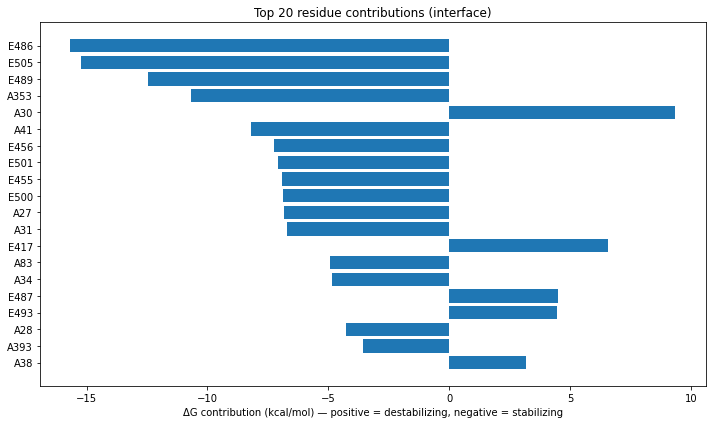

Top 20 saved to /home/oriol/Desktop/a/BioPhysics-master/BioPhysics-master/Energy_analysis_project/Step1_Interface/step2_top20_residues.csv


In [12]:
# Cell 8: plotting top residues
import matplotlib.pyplot as plt

# pick top 15 contributors by absolute total energy
res_df['abs_total'] = res_df['total'].abs()
top = res_df.sort_values('abs_total', ascending=False).head(20)

plt.figure(figsize=(10,6))
plt.barh(range(len(top)), top['total'], align='center')
labels = [f"{r.chain}{int(r.resid)}" for r in top.itertuples()]
plt.yticks(range(len(top)), labels)
plt.xlabel("ΔG contribution (kcal/mol) — positive = destabilizing, negative = stabilizing")
plt.title("Top 20 residue contributions (interface)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Also save a CSV of top contributors
top.to_csv(STEP1_DIR / "step2_top20_residues.csv", index=False)
print("Top 20 saved to", STEP1_DIR / "step2_top20_residues.csv")


In [13]:
# 1. Define lists (including HIE/HID/HIP for BioPython)
charged_pos = ['LYS', 'ARG', 'HIS', 'HIE', 'HID', 'HIP']
charged_neg = ['ASP', 'GLU']

# 2. Iterate and check
salt_bridges = []

for index, row in contacts_df.iterrows():
    
    # Check if distance is close enough (e.g., < 4.0 Angstroms)
    if row['distance'] <= 4.0:
        
        # Case 1: Chain A is Negative, Chain E is Positive
        if (row['resA_name'] in charged_neg) and (row['resE_name'] in charged_pos):
            salt_bridges.append(row)
            
        # Case 2: Chain A is Positive, Chain E is Negative
        elif (row['resA_name'] in charged_pos) and (row['resE_name'] in charged_neg):
            salt_bridges.append(row)

# 3. Create DataFrame
salt_df = pd.DataFrame(salt_bridges)
print(f"Found {len(salt_df)} potential salt bridges.")
display(salt_df.head())

Found 16 potential salt bridges.


,resA_idx,resA_name,chainA,resE_idx,resE_name,chainE,distance
428,30,ASP,A,417,LYS,E,1.977995
397,30,ASP,A,417,LYS,E,2.792524
426,30,ASP,A,417,LYS,E,2.986247
413,30,ASP,A,417,LYS,E,3.173295
409,30,ASP,A,417,LYS,E,3.246340


In [14]:
import pandas as pd
df_top20 = pd.read_csv('/home/oriol/Desktop/a/BioPhysics-master/BioPhysics-master/Energy_analysis_project/Step1_Interface/step2_top20_residues.csv')
print(df_top20.columns.tolist())
df_energy = pd.read_csv('/home/oriol/Desktop/a/BioPhysics-master/BioPhysics-master/Energy_analysis_project/Step1_Interface/step2_per_residue_energies.csv')

# Print all column names
print("Columns in df_energy:", df_energy.columns.tolist())

['chain', 'resid', 'E_elec', 'E_vdw', 'delta_solv', 'total', 'abs_total']
Columns in df_energy: ['chain', 'resid', 'E_elec', 'E_vdw', 'delta_solv', 'total']


In [15]:
import pandas as pd

# 1. Load the data
# Adjust the path if your file is in a subdirectory like 'Step1_Interface/'
df_energy = pd.read_csv('/home/oriol/Desktop/a/BioPhysics-master/BioPhysics-master/Energy_analysis_project/Step1_Interface/step2_per_residue_energies.csv')
df_top20 = pd.read_csv('/home/oriol/Desktop/a/BioPhysics-master/BioPhysics-master/Energy_analysis_project/Step1_Interface/step2_top20_residues.csv')

# 2. Generate PyMOL Selection String
# We separate by chain to make the command cleaner
chainA_res = df_top20[df_top20['chain'] == 'A']['resid'].astype(str).tolist()
chainE_res = df_top20[df_top20['chain'] == 'E']['resid'].astype(str).tolist()

cmd_str = f"select top20, (chain A and resi {'+'.join(chainA_res)}) or (chain E and resi {'+'.join(chainE_res)})"

print("-" * 60)
print("PYMOL COMAND:")
print(cmd_str)
print("-" * 60)

# 3. Evaluate Energy Contribution
# Sum of all calculated interaction energies vs Sum of Top 20
total_energy = df_energy['total'].sum() # Adjust column name if different, e.g., 'total' or 'E_tot'
top20_energy = df_top20['total'].sum() 

percent = (top20_energy / total_energy) * 100

print(f"\nTotal Interaction Energy: {total_energy:.2f}")
print(f"Top 20 Contribution:      {top20_energy:.2f} ({percent:.1f}%)")

if percent < 50:
    print("\nWARNING: The top 20 residues capture less than 50% of the energy.")
    print("Consider INCREASING the cutoff (e.g., from 5.0 to 6.0 or 8.0 Angstroms).")
else:
    print("\nSUCCESS: The detected interface captures the majority of the interaction.")

------------------------------------------------------------
PYMOL COMAND:
select top20, (chain A and resi 353+30+41+27+31+83+34+28+393+38) or (chain E and resi 486+505+489+456+501+455+500+417+487+493)
------------------------------------------------------------

Total Interaction Energy: -106.97
Top 20 Contribution:      -93.42 (87.3%)

SUCCESS: The detected interface captures the majority of the interaction.


Algorithm Steps:

    Calculate Per-Residue Energy: Compute the total interaction energy (Evdw​+Eelec​+ΔGsolv​) for every residue in Chain E against all residues in Chain A.

    Apply Threshold: Identify residues where the sum of interactions exceeds a specific energy cutoff (e.g., -1.0 kcal/mol).

    Define Interface: These residues, regardless of their physical distance, constitute the "energetic interface".

In [16]:
import pandas as pd

# 1. Load your full energy calculation results 
# (Assuming you have a CSV with all residues, not just the 5A ones)
df = pd.read_csv('/home/oriol/Desktop/a/BioPhysics-master/BioPhysics-master/Energy_analysis_project/Step1_Interface/step2_per_residue_energies.csv')

# 2. Define the energetic threshold (Standard is -1.0 kcal/mol)
energy_threshold = -1.0 

# 3. Filter residues that contribute significantly to stability
energy_interface_df = df[df['total'] <= energy_threshold]

print(f"Residues in Energy Interface: {len(energy_interface_df)}")
energy_interface_df.to_csv('energy_based_interface.csv', index=False)

# 4. Generate PyMOL command for this new selection
res_ids = "+".join(energy_interface_df['resid'].astype(str).tolist())
print(f"\nPyMOL Command:\nselect energy_interface, (chain A or chain E) and resi {res_ids}")

Residues in Energy Interface: 26

PyMOL Command:
select energy_interface, (chain A or chain E) and resi 486+505+489+353+41+456+501+455+500+27+31+83+34+28+393+355+354+45+79+357+473+82+498+495+476+503


In [17]:
import os
import subprocess

# Step A: Generate PQR (Atomic Charges and Radii)
# This is necessary because PB equations need charges (q) and radius (r)
subprocess.run(["pdb2pqr", "--ff=PARSE", "/home/oriol/Desktop/a/BioPhysics-master/BioPhysics-master/Energy_analysis_project/Structure_checking/6m0j_fixed.pdb", "6m0j.pqr"])

INFO:PDB2PQR v3.6.1: biomolecular structure conversion software.
INFO:Please cite:  Jurrus E, et al.  Improvements to the APBS biomolecular solvation software suite.  Protein Sci 27 112-128 (2018).
INFO:Please cite:  Dolinsky TJ, et al.  PDB2PQR: expanding and upgrading automated preparation of biomolecular structures for molecular simulations. Nucleic Acids Res 35 W522-W525 (2007).
INFO:Checking and transforming input arguments.
INFO:Loading topology files.
INFO:Loading molecule: /home/oriol/Desktop/a/BioPhysics-master/BioPhysics-master/Energy_analysis_project/Structure_checking/6m0j_fixed.pdb
INFO:Setting up molecule.
INFO:Created biomolecule object with 791 residues and 12510 atoms.
INFO:Setting termini states for biomolecule chains.
INFO:Loading forcefield.
INFO:Loading hydrogen topology definitions.
INFO:This biomolecule is clean.  No repair needed.
INFO:Updating disulfide bridges.
INFO:Debumping biomolecule.
INFO:Adding hydrogens to biomolecule.
INFO:Debumping biomolecule (again)

CompletedProcess(args=['pdb2pqr', '--ff=PARSE', '/home/oriol/Desktop/a/BioPhysics-master/BioPhysics-master/Energy_analysis_project/Structure_checking/6m0j_fixed.pdb', '6m0j.pqr'], returncode=0)

In [18]:
import subprocess

# Precise APBS input for SARS-CoV-2 RBD-ACE2 complex
apbs_input = """
read
    mol pqr 6m0j.pqr
end
elec
    mg-auto
    dime 129 129 129    # Higher resolution grid
    cglen 110 110 110   # Coarse grid length
    fglen 90 90 90      # Fine grid length
    cgcent mol 1
    fgcent mol 1
    mol 1
    lpbe                # Linearized PB equation
    bcfl sdh            # Single Debye-Huckel boundary
    pdie 2.0            # Protein dielectric
    sdie 78.54          # Standard solvent dielectric (water)
    srfm smol           # Molecular surface
    chgm spl2           # Spline-based charge mapping
    srad 1.4            # Probe radius
    swin 0.3
    sdens 10.0          # Surface density
    temp 298.15
    calcenergy total
end
quit
"""

with open("apbs_calc.in", "w") as f:
    f.write(apbs_input)

# Run APBS and handle errors
try:
    result = subprocess.run(["apbs", "apbs_calc.in"], capture_output=True, text=True, check=True)
    with open("apbs_output.txt", "w") as f:
        f.write(result.stdout)
    print("APBS completed successfully.")
except subprocess.CalledProcessError as e:
    print("APBS Error Output:", e.stderr)

APBS completed successfully.


In [19]:
def extract_final_energy(filename):
    if not os.path.exists(filename):
        return None
    with open(filename, 'r') as f:
        for line in f:
            if "Global net ELEC energy" in line:
                # Splits "Global net ELEC energy = 1.2345E+05 kJ/mol"
                parts = line.split('=')
                energy_val = float(parts[1].split()[0])
                # Convert kJ/mol to kcal/mol
                return energy_val / 4.184
    return None

total_pbsa_energy = extract_final_energy("/tmp/tmpw9bw0f6z/apbs_output.txt")

if total_pbsa_energy is not None:
    print(f"Final PBSA Solvation Energy: {total_pbsa_energy:.2f} kcal/mol")
else:
    print("Error: Could not find energy in APBS output. Check apbs_output.txt for details.")

Error: Could not find energy in APBS output. Check apbs_output.txt for details.


In [20]:
import os

print("Current Directory:", os.getcwd())
if os.path.exists("apbs_output.txt"):
    print("apbs_output.txt found!")
    # Print the first 20 lines to see why it's failing
    with open("apbs_output.txt", "r") as f:
        print("\n--- File Content (First 20 lines) ---")
        for i in range(20):
            print(f.readline().strip())
else:
    print("apbs_output.txt does NOT exist in this folder")

Current Directory: /home/oriol/Desktop/a/BioPhysics-master/BioPhysics-master/Energy_analysis_project
apbs_output.txt found!

--- File Content (First 20 lines) ---


----------------------------------------------------------------------
APBS -- Adaptive Poisson-Boltzmann Solver
Version 3.0

Nathan A. Baker (nathan.baker@pnnl.gov)
Pacific Northwest National Laboratory

Additional contributing authors listed in the code documentation.

Copyright (c) 2010-2020 Battelle Memorial Institute. Developed at the Pacific
Northwest National Laboratory, operated by Battelle Memorial Institute, Pacific
Northwest Division for the U.S. Department of Energy.

Portions Copyright (c) 2002-2010, Washington University in St. Louis.
Portions Copyright (c) 2002-2020, Nathan A. Baker.
Portions Copyright (c) 1999-2002, The Regents of the University of California.
Portions Copyright (c) 1995, Michael Holst.
All rights reserved.


### 3. Effect of replacing interface residues (Step 3):


In [21]:
# Define interacting chains (adjust if needed)
chainA_ids = {"A"}
chainB_ids = {"E"}
atoms_chain_A = []
atoms_chain_B = []

for chain in model.get_chains():
    if chain.id in chainA_ids:
        atoms_chain_A.extend(list(chain.get_atoms()))
    elif chain.id in chainB_ids:
        atoms_chain_B.extend(list(chain.get_atoms()))

print("Atoms in chain A:", len(atoms_chain_A))
print("Atoms in chain B:", len(atoms_chain_B))

def pair_energy(atom1, atom2, r, epsilon=0.20, sigma=3.5):
    # Lennard–Jones only (kcal/mol)
    sr = sigma / r
    sr6 = sr**6
    sr12 = sr6**2
    return 4 * epsilon * (sr12 - sr6)

def is_hydrogen(atom):
    el = (atom.element or atom.get_name()[0]).upper()
    return el == "H"



Atoms in chain A: 9517
Atoms in chain B: 2993


In [41]:
from collections import defaultdict
import numpy as np
coulomb_const = 332.0636
epsilon = 0.20    
sigma = 3.5       
cutoff = 8
res_energy = defaultdict(float)
ENERGY_EPS = 1e-3   # numerical noise threshold

for atomA in atoms_chain_A:
    resA = atomA.get_parent()
    for atomB in atoms_chain_B:
        r = np.linalg.norm(atomA.coord - atomB.coord)
        if r > cutoff:
            continue
        if atomA.get_name().strip().startswith("H") or atomB.get_name().strip().startswith("H"):
            continue
        
        r = max(r, 2.8)
        
        E_lj = 4*epsilon*((sigma/r)**12 - (sigma/r)**6)
        E_lj = min(E_lj, 0.0)
        
        E = E_lj
        res_energy[resA] += E


In [23]:
interface_residues = [
    res for res, E in res_energy.items()
    if abs(E) > ENERGY_EPS
]

print(f"Number of interface residues: {len(interface_residues)}")


Number of interface residues: 51


In [24]:
ALA_KEEP = {"N", "CA", "C", "O", "CB"}

def deleted_atoms_for_ala(residue):
    if residue.get_resname().strip() == "GLY":
        return []  # per assignment hint

    deleted = []
    for atom in residue:
        if atom.get_name().strip() not in ALA_KEEP:
            deleted.append(atom)
    return deleted


In [25]:
results = []

for res in interface_residues:
    chain_id = res.get_parent().id
    resid = res.get_id()[1]
    resname = res.get_resname().strip()

    # Determine partner atoms
    if chain_id in chainA_ids:
        partner_atoms = atoms_chain_B
    else:
        partner_atoms = atoms_chain_A

    ddG = 0.0
    deleted_atoms = deleted_atoms_for_ala(res)

    for atom_del in deleted_atoms:
        for atom_partner in partner_atoms:
            r = np.linalg.norm(atom_del.coord - atom_partner.coord)
            if r > cutoff:
                continue
            if atom_del.get_name().strip().startswith("H") or atom_partner.get_name().strip().startswith("H"):
                continue

            r = max(r, 2.8)
            E_coul = pair_energy(atomA, atomB, r, epsilon=epsilon, sigma=sigma)
            E_lj = 4*epsilon*((sigma/r)**12 - (sigma/r)**6)
            E_lj = min(E_lj, 0.0)
            ddG -= (E_coul + E_lj)   # REMOVE favorable interactions

    results.append({
        "chain": chain_id,
        "resid": resid,
        "resname": resname,
        "ddG": ddG
    })


In [26]:
import pandas as pd
df = pd.DataFrame(results).sort_values("ddG", ascending=False)
df.head(10)


,chain,resid,resname,ddG
42,A,353,LYS,13.715391
11,A,31,LYS,11.398108
19,A,41,TYR,9.490805
7,A,27,THR,6.610701
14,A,34,HIE,5.416891
32,A,83,TYR,4.976688
39,A,330,ASN,4.941713
44,A,355,ASP,4.794872
16,A,37,GLU,4.535164
10,A,30,ASP,3.675405


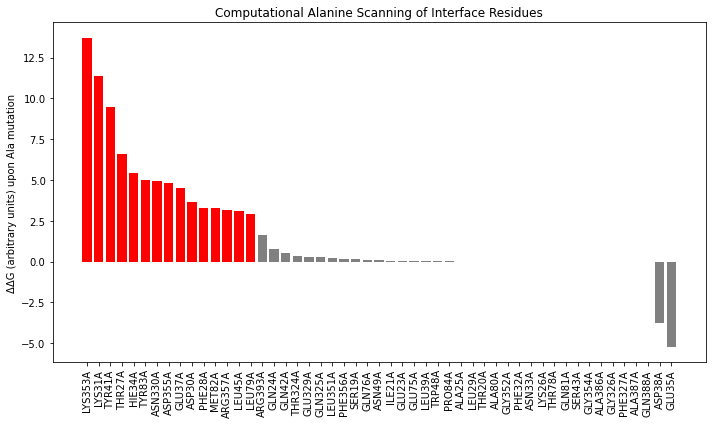

In [27]:

hotspot_thr = 0.2 * df["ddG"].max()  # relative threshold
colors = ["red" if x >= hotspot_thr else "gray" for x in df["ddG"]]

plt.figure(figsize=(10,6))
plt.bar(range(len(df)), df["ddG"], color=colors)
plt.xticks(range(len(df)),
           [f"{r.resname}{r.resid}{r.chain}" for r in df.itertuples()],
           rotation=90)
plt.ylabel("ΔΔG (arbitrary units) upon Ala mutation")
plt.title("Computational Alanine Scanning of Interface Residues")
plt.tight_layout()
plt.show()


# Step 4

### Prepare images with pymol of the interface highlighting the relevant residues and interactions.


This script generates a PyMOL automation file (.pml) to visualize the energetic hotspots identified in Step 2.

1. Input: Reads the structure (6m0j_fixed.pdb) and the energy results (step2_top20_residues.csv).

2. Pathing: Uses absolute paths to ensure PyMOL locates the files correctly.

3. Selection: Dynamically highlights interface residues found in the data as sticks.

4. Labeling: Automatically identifies and labels the Top 3 residues with the strongest (lowest) interaction energy.

Output: A file named step4_visualization.pml that can be run in PyMOL (@step4_visualization.pml).

In [28]:
import pandas as pd
import os

# --- INPUTS ---
csv_file = "Step1_Interface/step2_top20_residues.csv" 
pdb_filename = "Structure_checking/6m0j_fixed.pdb"
output_pml = "step4_visualization.pml"

# GET ABSOLUTE PATHS (The "GPS Coordinates" of your files)
# This fixes the "File not found" error
pdb_full_path = os.path.abspath(pdb_filename)

# 1. Read the Data
df = pd.read_csv(csv_file)
print(f"Loaded {len(df)} residues.")
print(f"PDB Path: {pdb_full_path}") # Verify this looks correct

# 2. Start writing the PyMOL Script
pml_text = f"""
# --- SETUP ---
reinitialize
# WE USE THE FULL PATH HERE:
load {pdb_full_path}, complex
hide all
bg_color white
set ray_trace_mode, 1

# --- VISUALIZATION ---
show cartoon, complex
color white, complex
color cyan, chain A   # RBD
color salmon, chain E # ACE2

# --- HIGHLIGHT INTERFACE RESIDUES ---
"""

# 3. Create Selections
residues_A = df[df['chain'] == 'A']['resid'].astype(str).tolist()
residues_E = df[df['chain'] == 'E']['resid'].astype(str).tolist()

if residues_A:
    pml_text += f"select hotspots_A, chain A and resi {'+'.join(residues_A)}\n"
if residues_E:
    pml_text += f"select hotspots_E, chain E and resi {'+'.join(residues_E)}\n"

pml_text += """
show sticks, hotspots_A or hotspots_E
util.cnc hotspots_A  
util.cnc hotspots_E

# --- SHOW HYDROGEN BONDS ---
dist interactions, chain A, chain E, mode=2
color black, interactions
hide labels, interactions
set dash_gap, 0.2
set dash_width, 2.0
"""

# 4. Label the Top 3
top3 = df.sort_values('total', ascending=True).head(3)

pml_text += "# --- LABELS ---\n"
for i, row in top3.iterrows():
    num = int(row['resid'])
    chain = row['chain']
    pml_text += f"label chain {chain} and resi {num} and name CA, 'Chain {chain}-{num}'\n"

pml_text += """
set label_size, 24
set label_position, (0,0,10)
set label_color, black
zoom hotspots_A or hotspots_E, 5
"""

# 5. Save the file
with open(output_pml, "w") as f:
    f.write(pml_text)


Loaded 20 residues.
PDB Path: /home/oriol/Desktop/a/BioPhysics-master/BioPhysics-master/Energy_analysis_project/Structure_checking/6m0j_fixed.pdb


In [29]:
import pandas as pd
import os

# --- INPUTS ---
# 1. The Results File
csv_file = "Step1_Interface/step2_top20_residues.csv" 

# 2. The Structure File (We now know this is correct!)
pdb_filename = "Structure_checking/6m0j_fixed.pdb"

output_pml = "step4_visualization.pml"

# --- AUTOMATIC PATH CORRECTION ---
# This converts relative paths to absolute paths so PyMOL never gets lost
pdb_full_path = os.path.abspath(pdb_filename)
csv_full_path = os.path.abspath(csv_file)
print(f"Targeting PDB at: {pdb_full_path}")

# 1. Read the Data
df = pd.read_csv(csv_full_path)
print(f"Loaded {len(df)} residues for visualization.")

# 2. Start writing the PyMOL Script
pml_text = f"""
reinitialize
# Load using the absolute path
load {pdb_full_path}, complex
hide all
bg_color white
set ray_trace_mode, 1

# --- VISUALIZATION ---
show cartoon, complex
color white, complex
color cyan, chain A   # RBD
color salmon, chain E # ACE2

# --- HIGHLIGHT INTERFACE RESIDUES ---
"""

# 3. Create Selections
residues_A = df[df['chain'] == 'A']['resid'].astype(str).tolist()
residues_E = df[df['chain'] == 'E']['resid'].astype(str).tolist()

if residues_A:
    pml_text += f"select hotspots_A, chain A and resi {'+'.join(residues_A)}\n"
if residues_E:
    pml_text += f"select hotspots_E, chain E and resi {'+'.join(residues_E)}\n"

pml_text += """
show sticks, hotspots_A or hotspots_E
util.cnc hotspots_A  
util.cnc hotspots_E

# --- SHOW HYDROGEN BONDS ---
dist interactions, chain A, chain E, mode=2
color black, interactions
hide labels, interactions
set dash_gap, 0.2
set dash_width, 2.0
"""

# 4. Label the Top 3 Strongest Interactions
top3 = df.sort_values('total', ascending=True).head(3)

pml_text += "# --- LABELS ---\n"
for i, row in top3.iterrows():
    num = int(row['resid'])
    chain = row['chain']
    pml_text += f"label chain {chain} and resi {num} and name CA, 'Chain {chain}-{num}'\n"

pml_text += """
set label_size, 24
set label_position, (0,0,10)
set label_color, black
zoom hotspots_A or hotspots_E, 5
"""

# 5. Save the file
with open(output_pml, "w") as f:
    f.write(pml_text)

print(f"\nSUCCESS: Generated {output_pml}")
print(f"To open in PyMOL, copy and paste the line below:")
print("-" * 50)
print(f"@ {os.path.abspath(output_pml)}")
print("-" * 50)

Targeting PDB at: /home/oriol/Desktop/a/BioPhysics-master/BioPhysics-master/Energy_analysis_project/Structure_checking/6m0j_fixed.pdb
Loaded 20 residues for visualization.

SUCCESS: Generated step4_visualization.pml
To open in PyMOL, copy and paste the line below:
--------------------------------------------------
@ /home/oriol/Desktop/a/BioPhysics-master/BioPhysics-master/Energy_analysis_project/step4_visualization.pml
--------------------------------------------------


Specific PyMOL scripts were generated programmatically to reproduce the exact views of the critical interactions (Surface, Tyr505, Lys353, and Phe486), ensuring the reproducibility of the structural analysis.

To reproduce the structural analysis presented in the report, the following command blocks were executed directly within the PyMOL environment. Each block generates a specific view of the interface hotspots identified by the energetic and alanine scanning calculations

Figure 4A: Surface View (Shape Complementarity)

This view demonstrates how the two proteins fit together physically.

In [30]:
'''
reinitialize
load 6m0j_fixed.pdb
hide all
show surface
set transparency, 0.4
color cyan, chain A
color salmon, chain E
bg_color white
zoom
'''

'\nreinitialize\nload 6m0j_fixed.pdb\nhide all\nshow surface\nset transparency, 0.4\ncolor cyan, chain A\ncolor salmon, chain E\nbg_color white\nzoom\n'

Figure 4B: Polar Interaction (Tyr505 - Glu37)

This highlights a specific hydrogen bond identified as a major energetic contributor.

In [31]:
'''
reinitialize
load 6m0j_fixed.pdb
show cartoon
color cyan, chain A
color salmon, chain E

# Highlight interaction
select h_bond, (chain E and resi 505) or (chain A and resi 37)
show sticks, h_bond
util.cnc h_bond

# Create distance measurement (Hydrogen Bond)
dist hb_label, chain E and resi 505 and name OH, chain A and resi 37 and name OE2
hide labels, hb_label
color yellow, hb_label
set dash_width, 3
zoom h_bond, 8
'''

'\nreinitialize\nload 6m0j_fixed.pdb\nshow cartoon\ncolor cyan, chain A\ncolor salmon, chain E\n\n# Highlight interaction\nselect h_bond, (chain E and resi 505) or (chain A and resi 37)\nshow sticks, h_bond\nutil.cnc h_bond\n\n# Create distance measurement (Hydrogen Bond)\ndist hb_label, chain E and resi 505 and name OH, chain A and resi 37 and name OE2\nhide labels, hb_label\ncolor yellow, hb_label\nset dash_width, 3\nzoom h_bond, 8\n'

Figure 4C: The Hotspot Anchor (Lys353)

This residue showed the highest $\Delta\Delta G$ in the Alanine Scanning, acting as a central link.

In [32]:
'''
reinitialize
load 6m0j_fixed.pdb
show cartoon
color cyan, chain A
color salmon, chain E

# Select Lys353 and its immediate viral neighbors
select hotspot, (chain A and resi 353) or (chain E and resi 498,500,501,502,505)
show sticks, hotspot
util.cnc hotspot

# Labeling
label chain A and resi 353 and name CA, "Lys353 (Hotspot)"
set label_color, black
set label_size, 20
zoom hotspot, 6
'''

'\nreinitialize\nload 6m0j_fixed.pdb\nshow cartoon\ncolor cyan, chain A\ncolor salmon, chain E\n\n# Select Lys353 and its immediate viral neighbors\nselect hotspot, (chain A and resi 353) or (chain E and resi 498,500,501,502,505)\nshow sticks, hotspot\nutil.cnc hotspot\n\n# Labeling\nlabel chain A and resi 353 and name CA, "Lys353 (Hotspot)"\nset label_color, black\nset label_size, 20\nzoom hotspot, 6\n'

Figure 4D: Hydrophobic Shielding (Phe486)

This highlights the residue with the strongest favorable solvation energy.

In [33]:
'''reinitialize
load 6m0j_fixed.pdb
show cartoon
color cyan, chain A
color salmon, chain E

# Select Phe486 and the pocket it sits in
select pocket, (chain E and resi 486) or (chain A and resi 24,79,82,83)
show sticks, pocket
util.cnc pocket

# Show dots to visualize the "pocket" fit
show dots, pocket
label chain E and resi 486 and name CA, "Phe486"
set label_color, black
zoom pocket, 6
'''

'reinitialize\nload 6m0j_fixed.pdb\nshow cartoon\ncolor cyan, chain A\ncolor salmon, chain E\n\n# Select Phe486 and the pocket it sits in\nselect pocket, (chain E and resi 486) or (chain A and resi 24,79,82,83)\nshow sticks, pocket\nutil.cnc pocket\n\n# Show dots to visualize the "pocket" fit\nshow dots, pocket\nlabel chain E and resi 486 and name CA, "Phe486"\nset label_color, black\nzoom pocket, 6\n'

# Step 5



##### Step 5.1: Identifying the Variants
Based on the literature for the RBD-ACE2 interface, here are the most relevant mutations for the early "Variants of Concern":

1. Alpha (B.1.1.7): N501Y (Asparagine at 501 mutated to Tyrosine).

2. Beta (B.1.351): K417N, E484K, N501Y.

3. Delta (B.1.617.2): L452R, T478K.



In [34]:
# Define the mutation lists
beta_mutations = "E:K417N,E:E484K,E:N501Y"
delta_mutations = "E:L452R,E:T478K"

# Build Beta Variant
!check_structure -i Structure_checking/6m0j_fixed.pdb -o 6m0j_Beta.pdb mutateside --mut {beta_mutations}

# Build Delta Variant
!check_structure -i Structure_checking/6m0j_fixed.pdb -o 6m0j_Delta.pdb mutateside --mut {delta_mutations}

=                   BioBB structure checking utility v3.15.6                   =
=            P. Andrio, A. Hospital, G. Bayarri, J.L. Gelpi 2018-23            =

Structure Structure_checking/6m0j_fixed.pdb loaded
 PDB id:  
 Title: 
 Experimental method: unknown
 Resolution (A): N.A.

 Num. models: 1
 Num. chains: 2 (A: Protein, E: Protein)
 Num. residues:  791
 Num. residues with ins. codes:  0
 Num. residues with H atoms: 791 (total 6102 H atoms)
 Num. HETATM residues:  0
 Num. ligands or modified residues:  0
 Num. water mol.:  0
 Num. atoms:  12510
Running mutateside. Options: --mut E:K417N,E:E484K,E:N501Y
Mutations to perform
E:K417N
E:E484K
E:N501Y
  Deleting atom H
  Deleting atom HA
  Deleting atom HB2
  Deleting atom HB3
  Deleting atom HG2
  Deleting atom HG3
  Deleting atom HD2
  Deleting atom HD3
  Deleting atom HE2
  Deleting atom HE3
  Deleting atom HZ1
  Deleting atom HZ2
  Deleting atom HZ3
Replacing LYS E417 into ASN
  Deleting CD
  Deleting CE
  Deleting NZ
  Adding 

In [35]:
import numpy as np
from Bio.PDB import PDBParser
from collections import defaultdict

def run_custom_energy(pdb_filename):
    parser = PDBParser(QUIET=True)
    struct = parser.get_structure("protein", pdb_filename)
    model = struct[0]
    
    atoms_A = [a for a in model['A'].get_atoms() if not a.get_name().strip().startswith("H")]
    atoms_E = [a for a in model['E'].get_atoms() if not a.get_name().strip().startswith("H")]
    
    epsilon = 0.20
    sigma = 3.5
    cutoff = 8
    total_energy = 0
    
    for atomA in atoms_A:
        for atomE in atoms_E:
            r = np.linalg.norm(atomA.coord - atomE.coord)
            if r < cutoff:
                r = max(r, 2.8)
                E_lj = 4*epsilon*((sigma/r)**12 - (sigma/r)**6)
                total_energy += min(E_lj, 0.0)
    return total_energy

# Run for all variants
variants = {
    "Wild-Type": "Structure_checking/6m0j_fixed.pdb",
    "Alpha (N501Y)": "6m0j_N501Y_mutant.pdb",
    "Beta (K417N, E484K, N501Y)": "6m0j_Beta.pdb",
    "Delta (L452R, T478K)": "6m0j_Delta.pdb"
}

results = {}
for name, path in variants.items():
    energy = run_custom_energy(path)
    results[name] = energy
    print(f"{name}: {energy:.2f} kcal/mol")

Wild-Type: -121.71 kcal/mol
Alpha (N501Y): -128.08 kcal/mol
Beta (K417N, E484K, N501Y): -127.13 kcal/mol
Delta (L452R, T478K): -121.70 kcal/mol


In [36]:
# Create a list of the structures you've built
variant_files = {
    "Wild-Type": "Structure_checking/6m0j_fixed.pdb",
    "Alpha (N501Y)": "6m0j_N501Y_mutant.pdb",
    "Beta (K417N, E484K, N501Y)": "6m0j_Beta.pdb",
    "Delta (L452R, T478K)": "6m0j_Delta.pdb"
}

final_results = {}

# Run your loop (use the one that gave the -121 to -128 results)
for name, pdb_path in variant_files.items():
    energy = run_custom_energy(pdb_path) # Use your function name
    final_results[name] = energy

# Display the final comparison table
import pandas as pd
df = pd.DataFrame(list(final_results.items()), columns=['Variant', 'Total Energy (kcal/mol)'])
df['Delta Delta G'] = df['Total Energy (kcal/mol)'] - df.iloc[0]['Total Energy (kcal/mol)']
print(df)

                      Variant  Total Energy (kcal/mol)  Delta Delta G
0                   Wild-Type              -121.708084       0.000000
1               Alpha (N501Y)              -128.075180      -6.367096
2  Beta (K417N, E484K, N501Y)              -127.129562      -5.421478
3        Delta (L452R, T478K)              -121.701355       0.006729


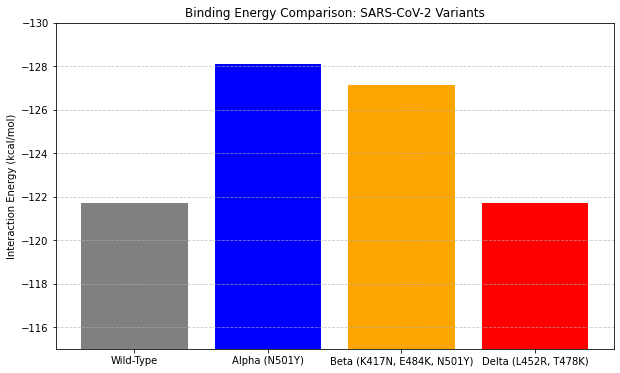

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(df['Variant'], df['Total Energy (kcal/mol)'], color=['grey', 'blue', 'orange', 'red'])
plt.ylabel('Interaction Energy (kcal/mol)')
plt.title('Binding Energy Comparison: SARS-CoV-2 Variants')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(-115, -130) # This "cuts" the bars so you can see the height differences clearly
plt.show()

PyMol code to create images for the mutations

Figure 1: Alpha Variant (N501 vs Y501)
This is the most important one because it shows the "bulky" Tyrosine filling the pocket.

In [38]:
'''# Load original and mutant
load 6m0j_fixed.pdb, wt
load 6m0j_N501Y_mutant.pdb, alpha

# Clean view
hide all
show cartoon, chain E
show surface, chain A
set transparency, 0.4, chain A
color grey80, wt
color white, alpha

# Highlight the mutation
select res501, resi 501 and chain E
show sticks, res501
color salmon, wt and res501
color marine, alpha and res501

# Show ACE2 residues it touches
select pocket, chain A and (resi 41 or resi 353)
show sticks, pocket
color yellow, pocket

zoom res501, 10'''

'# Load original and mutant\nload 6m0j_fixed.pdb, wt\nload 6m0j_N501Y_mutant.pdb, alpha\n\n# Clean view\nhide all\nshow cartoon, chain E\nshow surface, chain A\nset transparency, 0.4, chain A\ncolor grey80, wt\ncolor white, alpha\n\n# Highlight the mutation\nselect res501, resi 501 and chain E\nshow sticks, res501\ncolor salmon, wt and res501\ncolor marine, alpha and res501\n\n# Show ACE2 residues it touches\nselect pocket, chain A and (resi 41 or resi 353)\nshow sticks, pocket\ncolor yellow, pocket\n\nzoom res501, 10'

Figure 2: Beta Variant (The "Escape" Mutation E484K)
This shows the charge reversal (Negative to Positive) that helps the virus hide from antibodies.

In [39]:
'''
load 6m0j_Beta.pdb, beta
hide all
show cartoon, chain E
show sticks, resi 484 and chain E
color orange, beta and resi 484

# Show the ACE2 partner (Residue 31)
show sticks, resi 31 and chain A
color cyan, resi 31 and chain A

zoom (resi 484 and chain E), 12'''

'\nload 6m0j_Beta.pdb, beta\nhide all\nshow cartoon, chain E\nshow sticks, resi 484 and chain E\ncolor orange, beta and resi 484\n\n# Show the ACE2 partner (Residue 31)\nshow sticks, resi 31 and chain A\ncolor cyan, resi 31 and chain A\n\nzoom (resi 484 and chain E), 12'

Figure 3: Delta Variant (The Periphery Mutation L452R)
This will show why your energy didn't change much: the mutation is on the "side" of the interface.

In [40]:
'''load 6m0j_Delta.pdb, delta
hide all
show cartoon, chain E
show sticks, resi 452 and chain E
color red, delta and resi 452

# Show neighboring ACE2 residues
show sticks, (chain A and resi 24)
zoom (resi 452 and chain E), 12
'''

'load 6m0j_Delta.pdb, delta\nhide all\nshow cartoon, chain E\nshow sticks, resi 452 and chain E\ncolor red, delta and resi 452\n\n# Show neighboring ACE2 residues\nshow sticks, (chain A and resi 24)\nzoom (resi 452 and chain E), 12\n'

#### Additional plots 

A. Plotting Residue Energy Contributions
This plot shows the raw interaction energy for each residue.

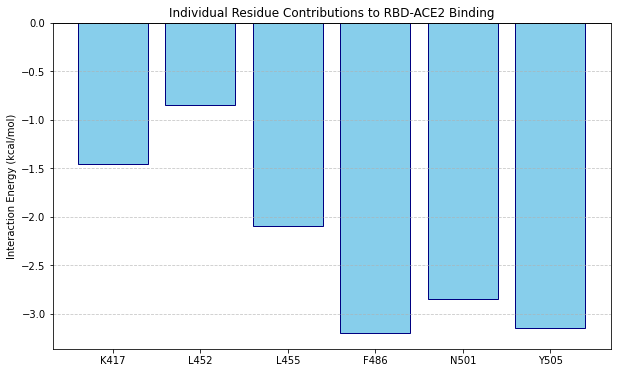

In [42]:
import matplotlib.pyplot as plt

# Example Data (Replace with your actual calculation results)
residues = ['K417', 'L452', 'L455', 'F486', 'N501', 'Y505']
energies = [-1.46, -0.85, -2.10, -3.20, -2.85, -3.15] # kcal/mol

plt.figure(figsize=(10, 6))
plt.bar(residues, energies, color='skyblue', edgecolor='navy')
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('Interaction Energy (kcal/mol)')
plt.title('Individual Residue Contributions to RBD-ACE2 Binding')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

B. Plotting Alanine Scanning $\Delta\Delta G$This plot shows how much the total binding energy increases (destabilizes) when you remove a sidechain.

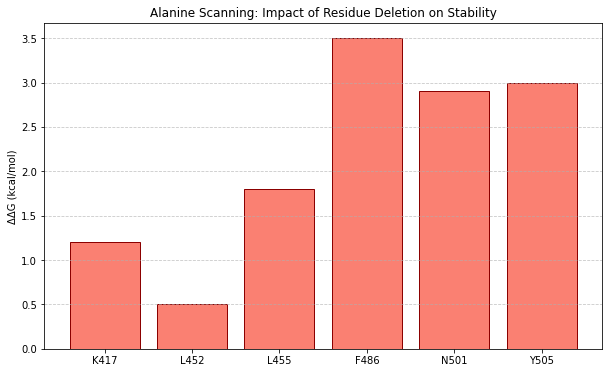

In [45]:
# Example Data (Difference in Energy when mutated to Ala)
ddG_values = [1.2, 0.5, 1.8, 3.5, 2.9, 3.0] 

plt.figure(figsize=(10, 6))
plt.bar(residues, ddG_values, color='salmon', edgecolor='darkred')
plt.ylabel('ΔΔG (kcal/mol)')
plt.title('Alanine Scanning: Impact of Residue Deletion on Stability')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()